In [3]:
import requests
from bs4 import BeautifulSoup
import json
import xlsxwriter

In [4]:
url = "https://www.youtube.com/c/GeeksforGeeksVideos/videos"
headers = {"User-Agent": "Mozilla/5.0"}
response = requests.get(url, headers=headers)
html = response.text

In [5]:
soup = BeautifulSoup(html, "html.parser")

In [6]:
script_tag = soup.find("script", text=lambda t: t and "var ytInitialData = " in t)
json_text = script_tag.string.strip()[len("var ytInitialData = "):-1]
data = json.loads(json_text)

C:\Users\yashi\AppData\Local\Temp\ipykernel_23460\3690196292.py:1: DeprecationWarning: The 'text' argument to find()-type methods is deprecated. Use 'string' instead.
  script_tag = soup.find("script", text=lambda t: t and "var ytInitialData = " in t)


In [7]:
videos_data = data['contents']['twoColumnBrowseResultsRenderer']['tabs'][1]\
              ['tabRenderer']['content']['richGridRenderer']['contents']

In [8]:
titles, views, durations = [], [], []
count = 0

for item in videos_data:
    try:
        video = item['richItemRenderer']['content']['videoRenderer']
        titles.append(video['title']['runs'][0]['text'])
        views.append(video.get('viewCountText', {}).get('simpleText', 'N/A'))
        durations.append(video.get('lengthText', {}).get('simpleText', 'N/A'))
        count += 1
        if count >= 30:
            break
    except:
        continue

In [9]:
workbook = xlsxwriter.Workbook("youtube_videos.xlsx")
sheet = workbook.add_worksheet()

sheet.write(0, 0, "Title")
sheet.write(0, 1, "Views")
sheet.write(0, 2, "Duration")

0

In [10]:
for i in range(len(titles)):
    sheet.write(i+1, 0, titles[i])
    sheet.write(i+1, 1, views[i])
    sheet.write(i+1, 2, durations[i])

In [11]:
workbook.close()
print("Scraped latest 30 videos successfully! Saved as youtube_videos.xlsx")

Scraped latest 30 videos successfully! Saved as youtube_videos.xlsx


In [12]:
import pandas as pd

data = pd.read_excel("youtube_videos.xlsx")
data.head()

,Title,Views,Duration
0,NIMCET 2026 Notification Released | Exam Date ...,"1,263 views",6:35
1,TCS NQT 2026 | How To register? | How To Apply...,"2,291 views",7:12
2,All About TCS NQT 2026 | Syllabus | Cut Off | ...,"14,256 views",10:05
3,What is SQL? 🤔 Future Career Scope & Best Reso...,"2,312 views",11:56
4,DSA In Java | Graph 01 | Java in One Shot | Gr...,"4,893 views",5:00:22


In [13]:
data['Views'] = data['Views'].str.replace(" views", "", regex=False).str.strip()
cleaned_views = []
for i in data['Views']:
    if pd.isna(i):  
        cleaned_views.append(None)
        continue

    i = str(i).replace(",", "")  

    if i.endswith('K') or i.endswith('k'):
        i = i.replace('K', '').replace('k', '')
        try:
            cleaned_views.append(float(i) * 1000)
        except:
            cleaned_views.append(None)
    else:
        try:
            cleaned_views.append(float(i))
        except:
            cleaned_views.append(None)

data['Views'] = cleaned_views

In [14]:
data['Duration'] = data['Duration'].str.replace("\n", "", regex=False)
def duration_to_seconds(duration_str):
    if pd.isna(duration_str) or duration_str in ['SHORTS', 'N/A']:
        return None
    parts = str(duration_str).split(':')
    if len(parts) == 3: 
        h, m, s = map(int, parts)
        return h * 3600 + m * 60 + s
    elif len(parts) == 2: 
        m, s = map(int, parts)
        return m * 60 + s
    return None

data['Duration'] = data['Duration'].apply(duration_to_seconds)

In [15]:
for i in data.index:
    val = data.loc[i, 'Duration']

    if val is None:
        continue
    elif val < 900:
        data.loc[i, 'Duration'] = 'Mini-Videos'
    elif val < 3600:
        data.loc[i, 'Duration'] = 'Long-Videos'
    else:
        data.loc[i, 'Duration'] = 'Very-Long-Videos'

data.head()

C:\Users\yashi\AppData\Local\Temp\ipykernel_23460\4002048857.py:7: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Mini-Videos' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  data.loc[i, 'Duration'] = 'Mini-Videos'


,Title,Views,Duration
0,NIMCET 2026 Notification Released | Exam Date ...,1263.0,Mini-Videos
1,TCS NQT 2026 | How To register? | How To Apply...,2291.0,Mini-Videos
2,All About TCS NQT 2026 | Syllabus | Cut Off | ...,14256.0,Mini-Videos
3,What is SQL? 🤔 Future Career Scope & Best Reso...,2312.0,Mini-Videos
4,DSA In Java | Graph 01 | Java in One Shot | Gr...,4893.0,Very-Long-Videos


In [16]:
import re
from tqdm import tqdm
import nltk

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem.porter import PorterStemmer

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\yashi\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\yashi\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\yashi\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [17]:
stop_words = set(stopwords.words('english'))
stemmer = PorterStemmer()

In [18]:
def preprocess_text(text_data):
    preprocessed_text = []

    for sentence in tqdm(text_data):
        sentence = str(sentence).lower()

        sentence = re.sub(r'http\S+|www\S+|https\S+', '', sentence)
       
        sentence = re.sub(r'[^a-z\s]', '', sentence)
       
        tokens = word_tokenize(sentence)

        tokens = [stemmer.stem(word) for word in tokens if word not in stop_words]

        preprocessed_text.append(" ".join(tokens))

    return preprocessed_text

In [19]:
data['Title'] = preprocess_text(data['Title'].values)
data.head()

100%|██████████| 30/30 [00:00<00:00, 264.34it/s]


,Title,Views,Duration
0,nimcet notif releas exam date syllabu onlin fo...,1263.0,Mini-Videos
1,tc nqt regist appli faq complet inform,2291.0,Mini-Videos
2,tc nqt syllabu cut elig ctc lakh,14256.0,Mini-Videos
3,sql futur career scope best resourc learn,2312.0,Mini-Videos
4,dsa java graph java one shot graph java,4893.0,Very-Long-Videos


In [2]:
!pip install requests beautifulsoup4 xlsxwriter --quiet

In [21]:
pip install wordcloud


Note: you may need to restart the kernel to use updated packages.


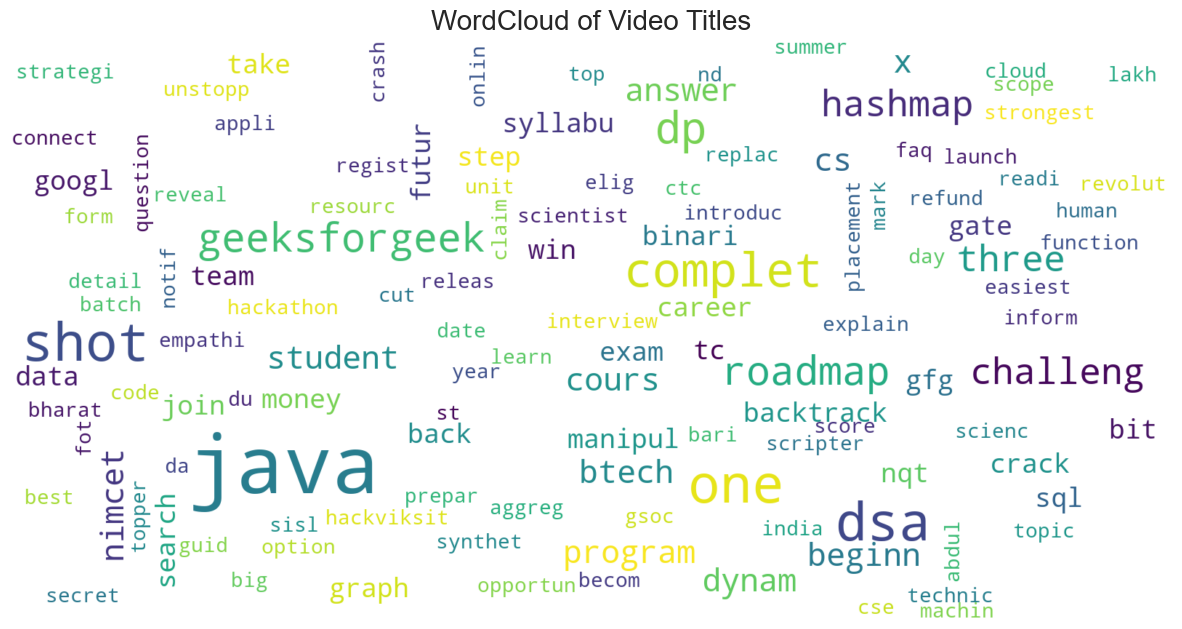

In [22]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

consolidated = ' '.join(word for word in data['Title'].astype(str))

wordCloud = WordCloud(
    width=1600, 
    height=800, 
    random_state=21,
    max_font_size=110, 
    collocations=False,
    background_color='white'
)

plt.figure(figsize=(15, 10))
plt.imshow(wordCloud.generate(consolidated), interpolation='bilinear')
plt.axis('off')
plt.title("WordCloud of Video Titles", fontsize=20)
plt.show()

C:\Users\yashi\AppData\Local\Temp\ipykernel_23460\1222352864.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


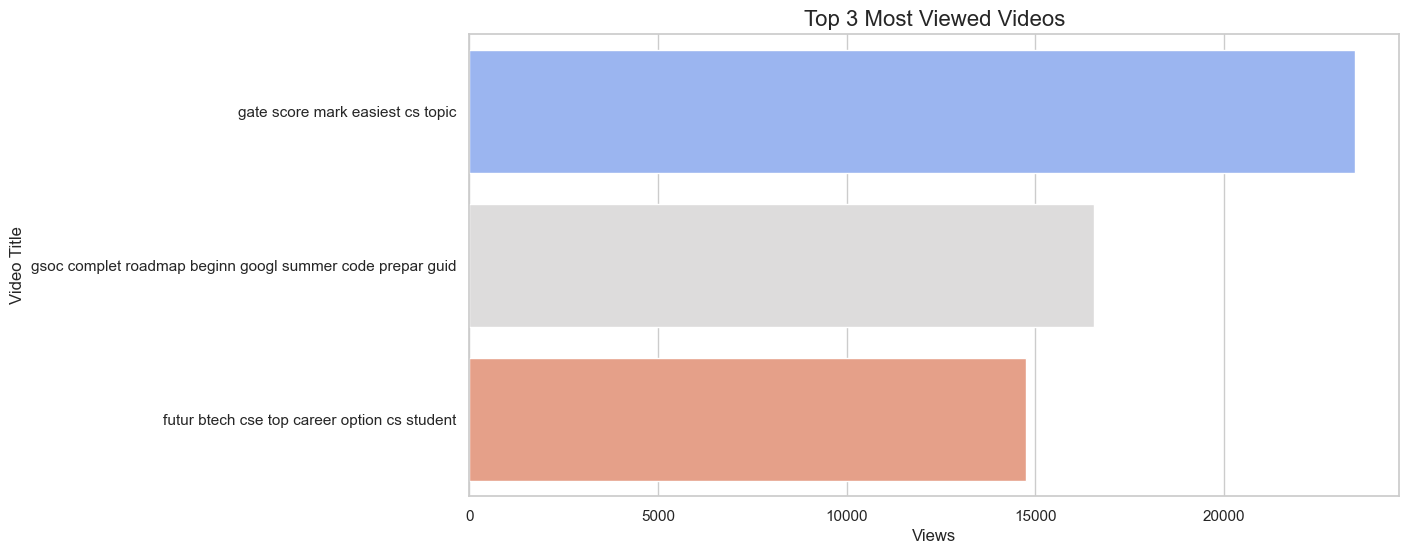

In [23]:
top_videos = data.sort_values(by='Views', ascending=False).head(3)

plt.figure(figsize=(12, 6))
sns.barplot(
    x='Views', 
    y='Title', 
    data=top_videos, 
    palette='coolwarm'
)
plt.title("Top 3 Most Viewed Videos", fontsize=16)
plt.xlabel("Views")
plt.ylabel("Video Title")
plt.show()

C:\Users\yashi\AppData\Local\Temp\ipykernel_23460\4206731473.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


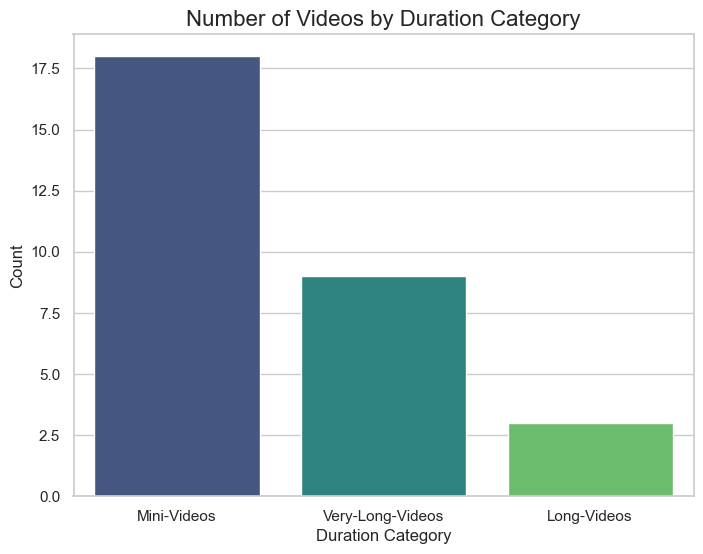

In [24]:
plt.figure(figsize=(8, 6))
sns.countplot(
    x='Duration', 
    data=data, 
    palette='viridis',
    order=data['Duration'].value_counts().index
)
plt.title("Number of Videos by Duration Category", fontsize=16)
plt.ylabel("Count")
plt.xlabel("Duration Category")
plt.show()